In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [16]:
# Rename columns to simple names
# Do this ONCE — fixes everything automatically
df = df.rename(columns={
    'Resume_str':  'Resume',
    'Resume_html': 'Resume_html'
})

# Drop HTML column — not needed
df = df.drop(columns=['Resume_html'])

print("Columns renamed and fixed!")
print(f"Columns now: {df.columns.tolist()}")
print(f"\nSample Resume text:")
print(df['Resume'].iloc[0][:200])

Columns renamed and fixed!
Columns now: ['ID', 'Resume', 'Category']

Sample Resume text:
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp


In [6]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [7]:
print("Resume Categories:")
print(df['Category'].value_counts())
print(f"\nTotal categories: {df['Category'].nunique()}")

Resume Categories:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

Total categories: 24


In [8]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Total missing: 0


In [13]:
print("Sample Resume Texts:")
print("=" * 60)
for i in range(3):
    print(f"\nResume {i+1}:")
    print(f"  Category: {df['Category'].iloc[i]}")
    print(f"  Text preview:")
    print(f"  {df['Resume_str'].iloc[i][:300]}")
    print("-" * 60)

Sample Resume Texts:

Resume 1:
  Category: HR
  Text preview:
           HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commit
------------------------------------------------------------

Resume 2:
  Category: HR
  Text preview:
           HR SPECIALIST, US HR OPERATIONS       Summary     Versatile  media professional with background in Communications, Marketing, Human Resources and Technology.Â         Experience     09/2015   to   Current     HR Specialist, US HR Operations    Company Name   ï¼   City  ,   State       Mana
------------------------------------------------------------

Resume 3:
  Category: HR
  Text preview:
           HR DIRECTOR       Summary      Over 20 years experience in recruiting,   15 plus years in Human Resources Executiv

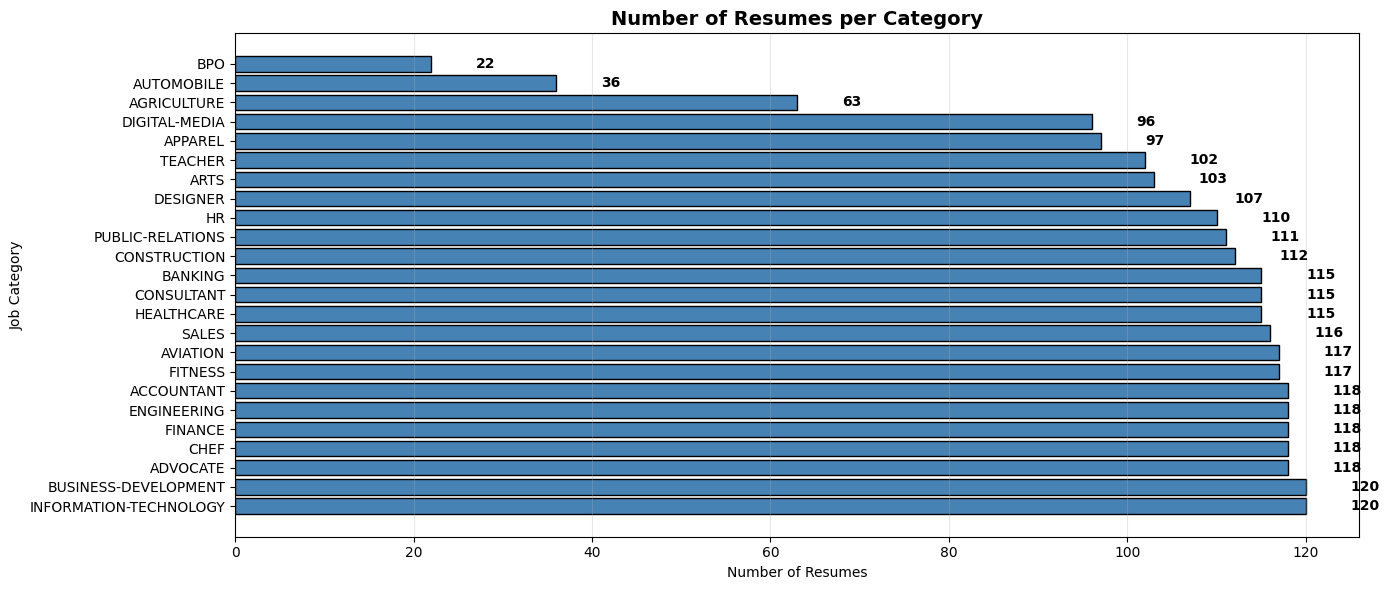

Chart saved!


In [14]:
plt.figure(figsize=(14, 6))
cat_counts = df['Category'].value_counts()

bars = plt.barh(cat_counts.index,
                cat_counts.values,
                color='steelblue',
                edgecolor='black')

for bar, val in zip(bars, cat_counts.values):
    plt.text(bar.get_width() + 5,
             bar.get_y() + bar.get_height()/2,
             str(val),
             va='center', fontweight='bold')

plt.title('Number of Resumes per Category',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Resumes')
plt.ylabel('Job Category')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../outputs/category_distribution.png')
plt.show()
print("Chart saved!")

In [15]:
# How long are the resumes?
df['word_count'] = df['Resume'].apply(
    lambda x: len(str(x).split())
)

print("Resume length statistics:")
print(f"  Average: {df['word_count'].mean():.0f} words")
print(f"  Minimum: {df['word_count'].min()} words")
print(f"  Maximum: {df['word_count'].max()} words")

plt.figure(figsize=(10, 4))
plt.hist(df['word_count'], bins=40,
         color='steelblue', edgecolor='black',
         alpha=0.7)
plt.axvline(x=df['word_count'].mean(),
            color='red', linestyle='--',
            label=f"Mean: {df['word_count'].mean():.0f} words")
plt.title('Resume Length Distribution', fontsize=14)
plt.xlabel('Number of Words')
plt.ylabel('Number of Resumes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/resume_length.png')
plt.show()

KeyError: 'Resume'

In [12]:
# Check exact column names
print("Exact column names:")
for i, col in enumerate(df.columns.tolist(), 1):
    print(f"  {i}. '{col}'")

print("\nFirst row preview:")
print(df.iloc[0])

Exact column names:
  1. 'ID'
  2. 'Resume_str'
  3. 'Resume_html'
  4. 'Category'

First row preview:
ID                                                      16852973
Resume_str              HR ADMINISTRATOR/MARKETING ASSOCIATE\...
Resume_html    <div class="fontsize fontface vmargins hmargin...
Category                                                      HR
Name: 0, dtype: object
